## CREDIT CARD FRAUD DETECTION PROJECT

### Problem Statement: To detect if a credit card transaction is genuine or fraud

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


### Loading dataset

In [2]:
df=pd.read_csv("creditcard.csv")

### Preliminary data preprocessing

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Class: Takes value 1 in case of fraud and 0 otherwise.
### There are mostly 0 values in the class so we need to check for random samples to know if this is a highly imbalanced dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### There are no missing values as all the columns have 284807 data

In [5]:
df.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
9576,14393.0,1.244378,0.629541,0.166585,1.389375,-0.020394,-1.322176,0.501503,-0.480868,0.924428,...,-0.117585,-0.031394,-0.103727,0.682555,0.796639,-0.357266,-0.032974,0.009853,8.31,0
105879,69731.0,-1.099359,0.485656,1.960178,-0.856214,-0.370435,-0.045546,0.113500,0.166708,1.051843,...,0.051045,0.079291,-0.060273,0.057338,-0.340332,-0.056713,-0.487970,0.053277,24.90,0
40517,40273.0,-5.729676,-2.727220,-1.850433,1.480017,-0.622292,-1.489764,0.047145,1.055986,0.474318,...,-0.246663,-0.111077,0.315458,0.401686,0.517800,0.472593,0.657967,-1.294780,20.00,0
19242,30118.0,-1.479080,1.219555,0.987283,-0.373321,0.399307,-0.243882,0.722081,-0.049666,0.675139,...,-0.464711,-0.671885,0.137278,-0.528642,0.022882,0.137236,0.546517,0.207710,8.99,0
232635,147244.0,-0.116847,0.831747,-1.683328,-1.581576,3.014612,3.264366,0.408181,0.828316,0.031035,...,0.335805,1.186413,-0.086514,0.735118,-0.706087,-0.194512,0.634770,0.375055,0.79,0
64153,51052.0,-1.281641,0.217622,2.137296,-0.300131,-1.192654,0.137803,-0.116590,0.317953,-0.817909,...,-0.244148,-0.136230,-0.041035,0.344190,-0.390760,-0.614908,-0.300712,-0.183705,84.00,0
161690,114431.0,1.919231,0.571736,-0.596745,3.841841,0.337165,-0.281015,0.232866,-0.209119,-0.956141,...,0.298613,1.004628,-0.016721,0.080705,0.239274,0.238422,-0.029431,-0.049755,10.62,0
160873,113717.0,0.004195,0.959160,-0.166491,-0.598910,1.056829,-0.030089,0.862217,-0.006848,-0.302910,...,0.390026,1.377613,-0.286495,0.266546,-0.345081,-0.425718,0.496736,0.279209,1.00,0
223941,143588.0,-1.280078,1.022611,1.694806,0.967398,-0.075978,-0.227922,0.066042,0.555432,-0.495774,...,-0.166564,-0.573688,-0.135765,-0.094032,0.353205,-0.657288,0.237829,0.031660,22.44,0
28,23.0,-0.414289,0.905437,1.727453,1.473471,0.007443,-0.200331,0.740228,-0.029247,-0.593392,...,0.077237,0.457331,-0.038500,0.642522,-0.183891,-0.277464,0.182687,0.152665,33.00,0


### In random samples of data also we are getting only 0 in class column so we need to know if this is an imbalanced dataset.

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df=df.drop_duplicates()

## Exploratory Data Analysis(EDA)

In [10]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

### from the value counts of class column we get to know that the data is highly imbalanced. we need to balance it later on. Also accuracy is not a reliable evaluation metric for such an imbalanced dataset.

<Axes: xlabel='Class', ylabel='count'>

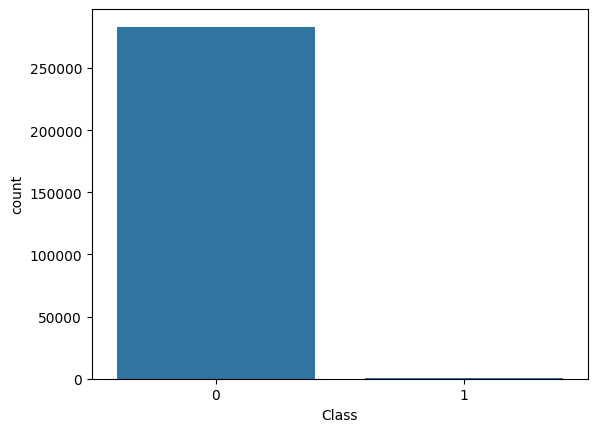

In [11]:
sns.countplot(x="Class",data=df)

### Mostly genuine transactions and very less fraud transactions. 

<Axes: xlabel='Amount', ylabel='Count'>

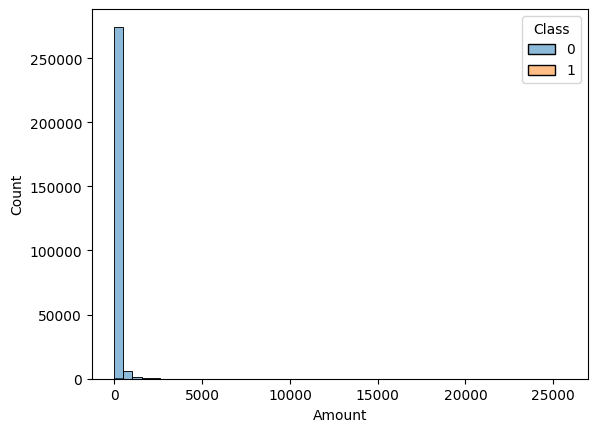

In [12]:
sns.histplot(data=df,x="Amount",bins=50,hue="Class")

### Most transactions have small amounts while a few have large amounts. 
### The distribution is right skewed. 

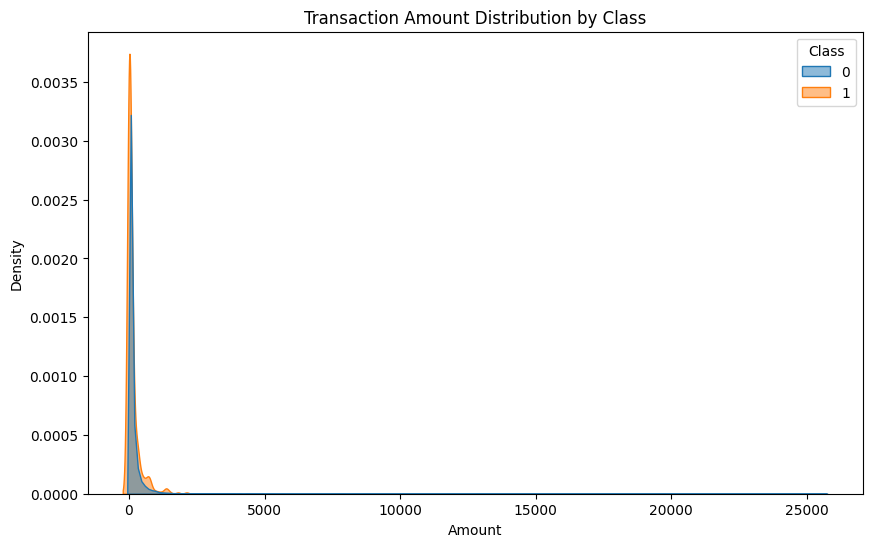

In [13]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="Amount",
    hue="Class",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Amount")

plt.show()

### The two curves overlap sigificantly so it is not possible to distinguish fraud from legitimate transactions based on the amount only.

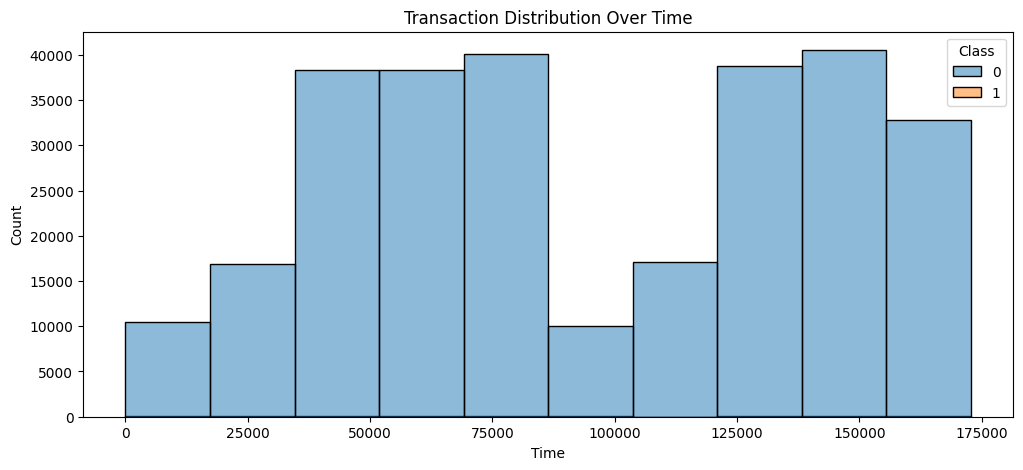

In [14]:
plt.figure(figsize=(12,5))

sns.histplot(data=df, x="Time", hue="Class", bins=10)

plt.title("Transaction Distribution Over Time")
plt.show()

### Transactions are spread over time and since there are more legitimate cases distinguishing is very difficult.

<Axes: >

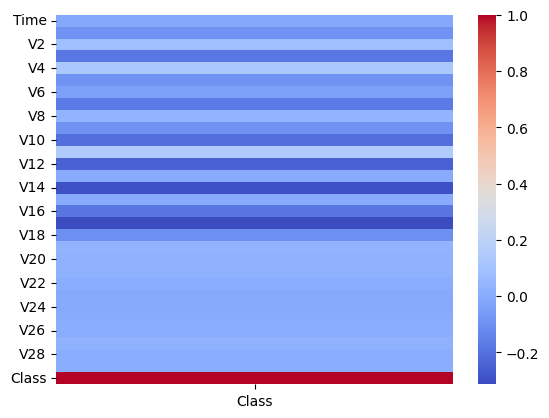

In [15]:
corr=df.corr()
sns.heatmap(corr[["Class"]],cmap="coolwarm")

### Negatively correlated: indirectly proportional to class are v14, v12, v17, v10.
### v20 to v 28 have very weak linear relation with the target.

### Outlier detection

<Axes: xlabel='Amount'>

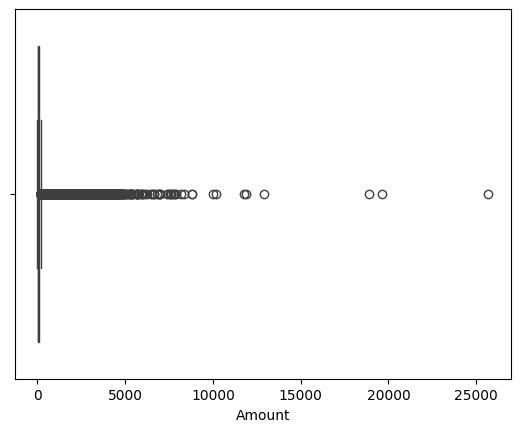

In [16]:
sns.boxplot(x=df["Amount"])

### very less large amount of transactions are present.

<Axes: xlabel='Class', ylabel='Amount'>

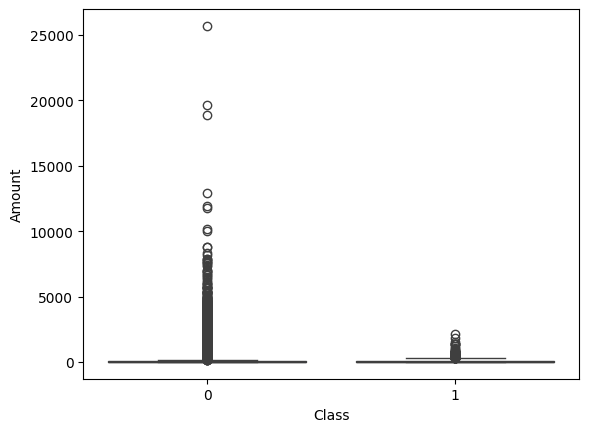

In [17]:
sns.boxplot(x="Class",y="Amount",data=df)

### Fraud transactions are occuring mostly in smaller ranges of amount.

In [18]:
q1= df["Amount"].quantile(0.25)
q3=df["Amount"].quantile(0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr

outliers=df[(df["Amount"]<lower) | (df["Amount"]>upper)]
print("Number of outliers is :",len(outliers))

Number of outliers is : 31685


In [19]:
percentage= len(outliers)/len(df)*100
print(f"percentage of outliers is {percentage}")

percentage of outliers is 11.1674643846528


### There are 11.16% of outliers. The transaction amount distribution is positively skewed because there a a small number of high-valued transactions. Outliers are retained because they may retain genuine high-value purcahses or fradulant activities. Removing them could hamper the model's capacity.

### Train test split

In [20]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.2,
                                               random_state=42
                                              )

### Feature scaling

In [22]:
scaler=StandardScaler()
X_train["Amount"]=scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"]=scaler.transform(X_test[["Amount"]])

### Imbalanced data management

In [23]:
smote=SMOTE(random_state=42)

In [24]:
X_train_resampled,y_train_resampled=smote.fit_resample(X_train,y_train)

In [25]:
y_train_resampled.value_counts()

Class
0    226597
1    226597
Name: count, dtype: int64

### The class imbalance is removed from the training set. We do so because we need all the original test data to be present. If we create fraud samples then the evaluation will be unrealistic.

### Applying ML models.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### creating pipeline

In [41]:
models={
    "lr": LogisticRegression(max_iter=1000,solver="saga"),
    "dt":DecisionTreeClassifier(),
    "rfc": RandomForestClassifier(),
    "xg":XGBClassifier()
}

In [28]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [29]:
X_small = X_train_resampled.sample(
    n=50000,
    random_state=42
)

y_small = y_train_resampled.loc[X_small.index]

### Since the dataset consistes of about 45000 rows after applying SMOTE training all the models was takimg a lot of time which is why we have taken small randomly sampled data of the X_train and y_train and used it to train the models.

In [30]:
results=[]
for name,model in models.items():
    model.fit(X_small,y_small)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]
    print(f"{name} trained")
    results.append([
    name,
    accuracy_score(y_test,y_pred),
    precision_score(y_test,y_pred),
    recall_score(y_test,y_pred),
    f1_score(y_test,y_pred),
    roc_auc_score(y_test,y_prob)
    ])

C:\Users\SHREYA PRIYADARSHINI\pythonlab\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


lr trained
dt trained
rfc trained
xg trained


In [31]:
result_df=pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_score",
        "Roc_Auc_score"
    ])

In [32]:
result_df

,Model,Accuracy,Precision,Recall,F1_score,Roc_Auc_score
0,lr,0.996493,0.220513,0.477778,0.301754,0.838838
1,dt,0.989074,0.106825,0.800000,0.188482,0.894687
2,rfc,0.998996,0.641026,0.833333,0.724638,0.972334
3,xg,0.998449,0.506849,0.822222,0.627119,0.967610


### Since the test data is still imbalanced accuracy is not reliable for such a dataset. so we check for recall,f1 score, roc and precision.

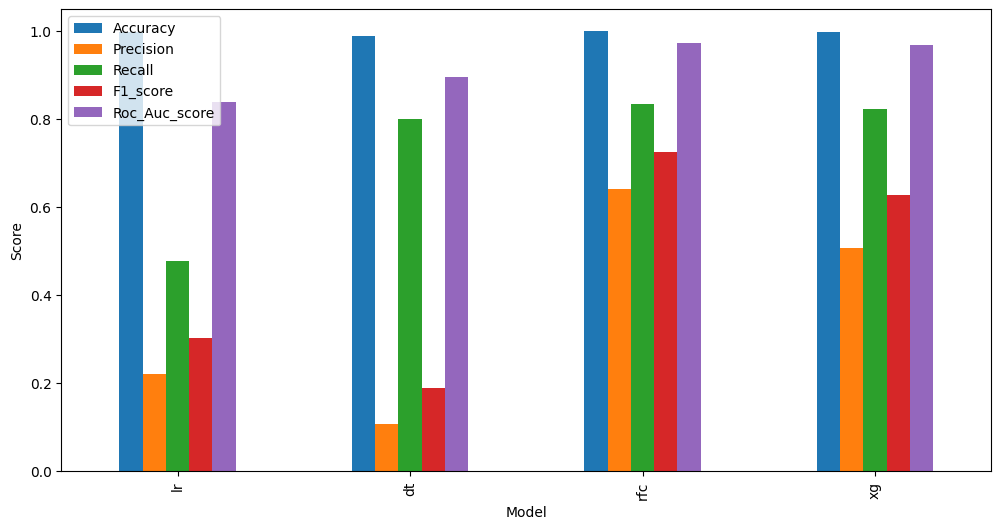

In [33]:
result_df.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylabel("Score")
plt.show()

### Among the models evaluated on a representative sample of the training data, Random Forest achieved the best overall performance and was therefore selected for full-scale training.

In [34]:
rfc=RandomForestClassifier(n_estimators=20,
    max_depth=8,
    n_jobs=-1,
    random_state=42)
rfc.fit(X_train_resampled,y_train_resampled)
y_pred=rfc.predict(X_test)

In [35]:
print(f" Accuracy score is : {accuracy_score(y_test,y_pred)}")
print(f" Precision score is : {precision_score(y_test,y_pred)}")
print(f" Recall score is : {recall_score(y_test,y_pred)}")
print(f" F1 score is : {f1_score(y_test,y_pred)}")
print(f" Roc auc curve score is : {roc_auc_score(y_test,y_prob)}")

 Accuracy score is : 0.9970218165157015
 Precision score is : 0.32599118942731276
 Recall score is : 0.8222222222222222
 F1 score is : 0.4668769716088328
 Roc auc curve score is : 0.9676103737174055


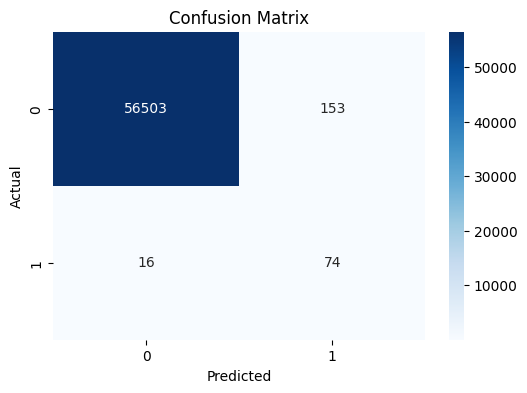

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rfc.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

   Feature  Importance
14     V14    0.369165
17     V17    0.156690
12     V12    0.086917
10     V10    0.076862
4       V4    0.074455
3       V3    0.071720
16     V16    0.038677
2       V2    0.028547
9       V9    0.024124
11     V11    0.009856


### V14 and V10 were identified as the most influential features by the Random Forest model and contributed significantly to distinguishing fraudulent and genuine transactions.

In [38]:
import joblib

joblib.dump(rfc, "fraud_model.pkl")

['fraud_model.pkl']

In [39]:
X_test.head(20).to_csv(
    "test_transactions.csv",
    index=False
)

### The above test dataset is created for the testing phase.